In [1]:
# =========================
# CELL 1: Install Libraries
# =========================

!pip install kagglehub tensorflow matplotlib scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 794.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 61.4 MB/s eta 0:00:00


In [2]:
# =========================
# CELL 2: Import Libraries
# =========================

import os
import shutil
import random
import kagglehub
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [3]:
# ==================================
# CELL 3: Download Kaggle Datasets
# ==================================

waste_path = kagglehub.dataset_download("techsash/waste-classification-data")
ewaste_path = kagglehub.dataset_download("akshat103/e-waste-image-dataset")

print("Waste dataset path:", waste_path)
print("E-waste dataset path:", ewaste_path)

Using Colab cache for faster access to the 'waste-classification-data' dataset.


100%|██████████| 11.8M/11.8M [00:00<00:00, 52.7MB/s]

Extracting files...


Waste dataset path: /kaggle/input/waste-classification-data
E-waste dataset path: /root/.cache/kagglehub/datasets/akshat103/e-waste-image-dataset/versions/1


In [4]:
# ==================================
# CELL 4: Check Dataset Structure
# ==================================

def show_folders(path):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, "").count(os.sep)
        indent = " " * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        if level > 2:
            break

print("Waste Dataset:")
show_folders(waste_path)

print("\nE-Waste Dataset:")
show_folders(ewaste_path)

Waste Dataset:
waste-classification-data/
  DATASET/
    TEST/
      R/

E-Waste Dataset:
1/
  modified-dataset/
    train/
      Mobile/


In [5]:
# =========================================================
# CELL 5: Create Final Combined Dataset
# Classes:
# Organic     -> Wet Waste
# Recyclable  -> Dry Waste
# E-Waste     -> E-Waste
# =========================================================

final_dataset = "/content/final_waste_dataset"

classes = ["wet_waste", "dry_waste", "e_waste"]

for cls in classes:
    os.makedirs(os.path.join(final_dataset, cls), exist_ok=True)

print("Final dataset folders created.")

Final dataset folders created.


In [6]:
# ==================================================
# CELL 6: Helper Function to Copy Images
# ==================================================

valid_ext = [".jpg", ".jpeg", ".png", ".webp"]

def copy_images(src_folder, dest_folder, prefix):
    count = 0

    for root, dirs, files in os.walk(src_folder):
        for file in files:
            if file.lower().endswith(tuple(valid_ext)):
                src_path = os.path.join(root, file)
                new_name = f"{prefix}_{count}_{file}"
                dest_path = os.path.join(dest_folder, new_name)

                try:
                    shutil.copy(src_path, dest_path)
                    count += 1
                except:
                    pass

    return count

In [7]:
# ==================================================
# CELL 7 + 8 FIXED: Copy O and R folders correctly
# ==================================================

import os
import shutil

# Use only main DATASET folder to avoid duplicate copy
waste_main_path = "/kaggle/input/waste-classification-data/DATASET"

organic_folders = [
    os.path.join(waste_main_path, "TRAIN", "O"),
    os.path.join(waste_main_path, "TEST", "O")
]

recyclable_folders = [
    os.path.join(waste_main_path, "TRAIN", "R"),
    os.path.join(waste_main_path, "TEST", "R")
]

print("Organic folders:", organic_folders)
print("Recyclable folders:", recyclable_folders)

wet_count = 0
dry_count = 0

for folder in organic_folders:
    wet_count += copy_images(
        folder,
        os.path.join(final_dataset, "wet_waste"),
        "wet"
    )

for folder in recyclable_folders:
    dry_count += copy_images(
        folder,
        os.path.join(final_dataset, "dry_waste"),
        "dry"
    )

print("Wet waste images copied:", wet_count)
print("Dry waste images copied:", dry_count)

Organic folders: ['/kaggle/input/waste-classification-data/DATASET/TRAIN/O', '/kaggle/input/waste-classification-data/DATASET/TEST/O']
Recyclable folders: ['/kaggle/input/waste-classification-data/DATASET/TRAIN/R', '/kaggle/input/waste-classification-data/DATASET/TEST/R']
Wet waste images copied: 13966
Dry waste images copied: 11111


In [8]:
# ==================================================
# CELL 9: Copy All E-Waste Images
# ==================================================

e_count = copy_images(
    ewaste_path,
    os.path.join(final_dataset, "e_waste"),
    "ewaste"
)

print("E-waste images:", e_count)

E-waste images: 3000


In [9]:
# ==================================================
# CELL 10: Check Final Class Count
# ==================================================

for cls in classes:
    folder = os.path.join(final_dataset, cls)
    print(cls, ":", len(os.listdir(folder)))

wet_waste : 13966
dry_waste : 11111
e_waste : 3000


wet_waste image count: 13966
dry_waste image count: 11111
e_waste image count: 3000


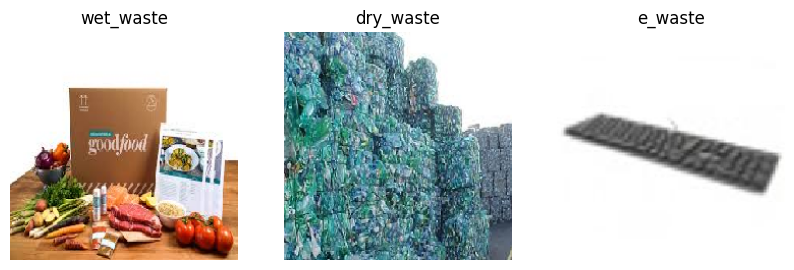

In [10]:
# ==================================================
# CELL 11 FIXED: Show Sample Images Safely
# ==================================================

plt.figure(figsize=(10, 6))

plot_index = 1

for cls in classes:
    folder = os.path.join(final_dataset, cls)
    files = os.listdir(folder)

    print(cls, "image count:", len(files))

    if len(files) == 0:
        print(f"No images found in {cls}")
        continue

    img_name = random.choice(files)
    img_path = os.path.join(folder, img_name)

    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))

    plt.subplot(1, 3, plot_index)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

    plot_index += 1

plt.show()

In [11]:
# ==================================================
# CELL 12: Train-Test Split Folder Creation
# ==================================================

split_dataset = "/content/split_waste_dataset"

train_dir = os.path.join(split_dataset, "train")
val_dir = os.path.join(split_dataset, "val")
test_dir = os.path.join(split_dataset, "test")

for base in [train_dir, val_dir, test_dir]:
    for cls in classes:
        os.makedirs(os.path.join(base, cls), exist_ok=True)

for cls in classes:
    cls_folder = os.path.join(final_dataset, cls)
    images = os.listdir(cls_folder)

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42
    )

    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_folder, img),
            os.path.join(train_dir, cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(cls_folder, img),
            os.path.join(val_dir, cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(cls_folder, img),
            os.path.join(test_dir, cls, img)
        )

print("Dataset split completed.")

Dataset split completed.


In [12]:
for cls in classes:
    folder = os.path.join(final_dataset, cls)
    print(cls, ":", len(os.listdir(folder)))

wet_waste : 13966
dry_waste : 11111
e_waste : 3000


In [13]:
# ==================================================
# CELL 13: Image Data Generator
# ==================================================

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(train_data.class_indices)

Found 19653 images belonging to 3 classes.
Found 4212 images belonging to 3 classes.
Found 4212 images belonging to 3 classes.
{'dry_waste': 0, 'e_waste': 1, 'wet_waste': 2}


In [14]:
# ==================================================
# CELL 14: Build MobileNetV2 Model
# ==================================================

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# ==================================================
# CELL 15: Train Model
# ==================================================

checkpoint = ModelCheckpoint(
    "best_waste_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/10
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.8472 - loss: 0.4071
Epoch 1: val_accuracy improved from None to 0.92735, saving model to best_waste_model.h5



Epoch 1: finished saving model to best_waste_model.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 531s 858ms/step - accuracy: 0.8891 - loss: 0.3015 - val_accuracy: 0.9274 - val_loss: 0.1905
Epoch 2/10
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.9125 - loss: 0.2293
Epoch 2: val_accuracy improved from 0.92735 to 0.93186, saving model to best_waste_model.h5



Epoch 2: finished saving model to best_waste_model.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 520s 846ms/step - accuracy: 0.9146 - loss: 0.2253 - val_accuracy: 0.9319 - val_loss: 0.1782
Epoch 3/10
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.9262 - loss: 0.1958
Epoch 3: val_accuracy improved from 0.93186 to 0.93613, saving model to best_waste_model.h5



Epoch 3: finished saving model to best_waste_model.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 523s 851ms/step - accuracy: 0.9249 - loss: 0.2016 - val_accuracy: 0.9361 - val_loss: 0.1671
Epoch 4/10
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.9302 - loss: 0.1904
Epoch 4: val_accuracy improved from 0.93613 to 0.93898, saving model to best_waste_model.h5



Epoch 4: finished saving model to best_waste_model.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 523s 851ms/step - accuracy: 0.9320 - loss: 0.1845 - val_accuracy: 0.9390 - val_loss: 0.1730
Epoch 5/10
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9372 - loss: 0.1680
Epoch 5: val_accuracy did not improve from 0.93898
615/615 ━━━━━━━━━━━━━━━━━━━━ 561s 913ms/step - accuracy: 0.9342 - loss: 0.1757 - val_accuracy: 0.9361 - val_loss: 0.1579
Epoch 6/10
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - accuracy: 0.9382 - loss: 0.1599
Epoch 6: val_accuracy improved from 0.93898 to 0.94587, saving model to best_waste_model.h5



Epoch 6: finished saving model to best_waste_model.h5
615/615 ━━━━━━━━━━━━━━━━━━━━ 552s 897ms/step - accuracy: 0.9364 - loss: 0.1690 - val_accuracy: 0.9459 - val_loss: 0.1524
Epoch 7/10
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.9417 - loss: 0.1572
Epoch 7: val_accuracy did not improve from 0.94587
615/615 ━━━━━━━━━━━━━━━━━━━━ 573s 932ms/step - accuracy: 0.9407 - loss: 0.1592 - val_accuracy: 0.9406 - val_loss: 0.1599
Epoch 8/10
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.9408 - loss: 0.1546
Epoch 8: val_accuracy did not improve from 0.94587
615/615 ━━━━━━━━━━━━━━━━━━━━ 565s 918ms/step - accuracy: 0.9414 - loss: 0.1569 - val_accuracy: 0.9418 - val_loss: 0.1564
Epoch 9/10
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.9441 - loss: 0.1474
Epoch 9: val_accuracy did not improve from 0.94587
615/615 ━━━━━━━━━━━━━━━━━━━━ 520s 846ms/step - accuracy: 0.9437 - loss: 0.1519 - val_accuracy: 0.9456 - val_loss: 0.1505
Epoch 10/10
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 

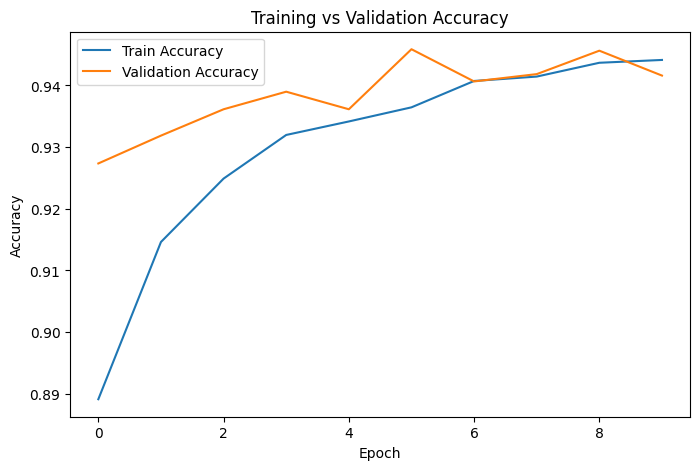

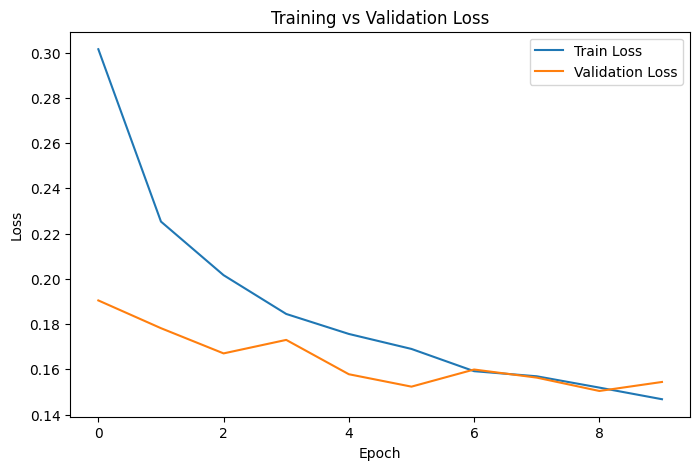

In [16]:
# ==================================================
# CELL 16: Accuracy and Loss Graph
# ==================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [17]:
# ==================================================
# CELL 17: Test Evaluation
# ==================================================

loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

132/132 ━━━━━━━━━━━━━━━━━━━━ 88s 669ms/step - accuracy: 0.9442 - loss: 0.1545
Test Loss: 0.15446403622627258
Test Accuracy: 0.9442070126533508


In [18]:
# ==================================================
# CELL 18: Classification Report
# ==================================================

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

class_names = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

132/132 ━━━━━━━━━━━━━━━━━━━━ 89s 668ms/step
              precision    recall  f1-score   support

   dry_waste       0.94      0.93      0.93      1667
     e_waste       0.95      0.97      0.96       450
   wet_waste       0.95      0.95      0.95      2095

    accuracy                           0.94      4212
   macro avg       0.95      0.95      0.95      4212
weighted avg       0.94      0.94      0.94      4212



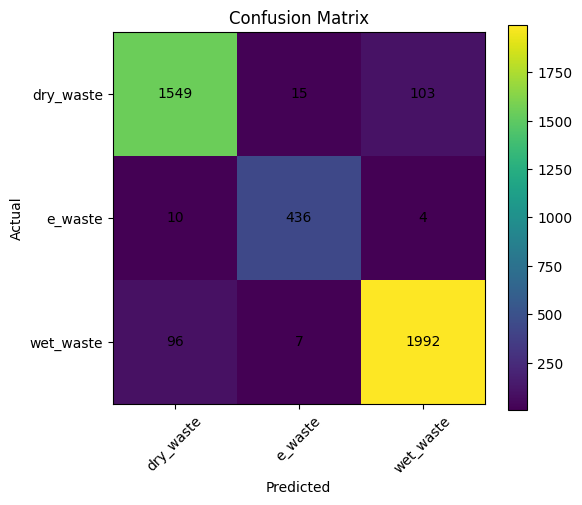

In [19]:
# ==================================================
# CELL 19: Confusion Matrix
# ==================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

Saving plastic_bottle.webp to plastic_bottle.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step


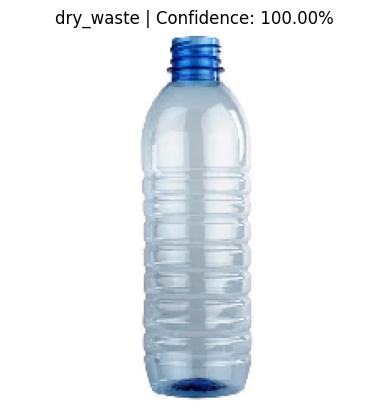

Predicted Class: dry_waste
Confidence: 99.99795
Recommended Bin: Blue Bin / Recycling Bin


In [20]:
# ==================================================
# CELL 20: Predict Single Image
# ==================================================

from google.colab import files

uploaded = files.upload()

idx_to_class = {v: k for k, v in train_data.class_indices.items()}

bin_mapping = {
    "wet_waste": "Green Bin / Compost Bin",
    "dry_waste": "Blue Bin / Recycling Bin",
    "e_waste": "E-Waste Collection Bin"
}

for file_name in uploaded.keys():
    img = tf.keras.utils.load_img(file_name, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_class = idx_to_class[np.argmax(pred)]
    confidence = np.max(pred) * 100

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{pred_class} | Confidence: {confidence:.2f}%")
    plt.show()

    print("Predicted Class:", pred_class)
    print("Confidence:", confidence)
    print("Recommended Bin:", bin_mapping[pred_class])

In [21]:
# ==================================================
# CELL 21: Save Final Model
# ==================================================

model.save("/content/final_waste_detector_model.h5")

print("Model saved successfully.")

Model saved successfully.


In [1]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
!ls /content/
!ls /content/split_waste_dataset/train

sample_data
ls: cannot access '/content/split_waste_dataset/train': No such file or directory
